In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [7]:
import pandas as pd

url = "https://www.lock5stat.com/datasets3e/MustangPrice.csv"

df = pd.read_csv(url)

print("=" * 50)
print("CAR DATASET")
print("=" * 50)

print(f"Shape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

CAR DATASET
Shape: (25, 3)

First 5 rows:


,Age,Miles,Price
0,6,8.5,32.0
1,7,33.0,45.0
2,9,82.8,11.9
3,2,7.0,24.8
4,3,23.0,22.0



Column names:
['Age', 'Miles', 'Price']

Data types:
Age        int64
Miles    float64
Price    float64
dtype: object

Missing values:
Age      0
Miles    0
Price    0
dtype: int64


In [15]:
THRESHOLD = df["Price"].median()

df["premium"] = (df["Price"] >= THRESHOLD).astype(int)

print("=" * 50)
print("TARGET VARIABLE")
print("=" * 50)

print(f"Median price threshold: ${THRESHOLD:.2f} thousand")

print("\nClass distribution:")
print(df["premium"].value_counts().sort_index())

print("\nClass percentages:")
print(df["premium"].value_counts(normalize=True).sort_index())

TARGET VARIABLE
Median price threshold: $11.90 thousand

Class distribution:
premium
0    12
1    13
Name: count, dtype: int64

Class percentages:
premium
0    0.48
1    0.52
Name: proportion, dtype: float64


In [16]:
print("=" * 50)
print("CLASS CHECK")
print("=" * 50)

print("Regular cars (0):", (df["premium"] == 0).sum())
print("Premium cars (1):", (df["premium"] == 1).sum())

print("\nUnique classes:")
print(df["premium"].unique())

CLASS CHECK
Regular cars (0): 12
Premium cars (1): 13

Unique classes:
[1 0]


In [17]:
X = df[["Age", "Miles"]].values
y = df["premium"].values

print("=" * 50)
print("FEATURES & TARGET")
print("=" * 50)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("Feature names: Age, Miles")
print("Target: premium")
print("0 = Regular")
print("1 = Premium")

FEATURES & TARGET
Features shape: (25, 2)
Target shape: (25,)
Feature names: Age, Miles
Target: premium
0 = Regular
1 = Premium


In [18]:
RS = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RS,
    stratify=y
)

print("=" * 50)
print("DATA SPLIT")
print("=" * 50)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

print(f"Training premium share: {np.mean(y_train):.2%}")
print(f"Testing premium share: {np.mean(y_test):.2%}")

print("\nTraining classes:")
print(np.unique(y_train, return_counts=True))

print("\nTesting classes:")
print(np.unique(y_test, return_counts=True))

DATA SPLIT
Training data shape: (20, 2)
Testing data shape: (5, 2)
Training premium share: 50.00%
Testing premium share: 60.00%

Training classes:
(array([0, 1]), array([10, 10]))

Testing classes:
(array([0, 1]), array([2, 3]))


In [19]:
def pipe(model, scale=True):
    steps = []

    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", model))

    return Pipeline(steps)

In [20]:
logReg = pipe(
    LogisticRegression(
        max_iter=2000,
        random_state=RS
    ),
    scale=True
)

logReg.fit(X_train, y_train)

print("=" * 50)
print("MODEL TRAINED")
print("=" * 50)

print("Logistic Regression trained successfully!")

MODEL TRAINED
Logistic Regression trained successfully!


In [21]:
y_pred = logReg.predict(X_test)

y_proba = logReg.predict_proba(X_test)[:, 1]

print("=" * 50)
print("PREDICTIONS")
print("=" * 50)

print(f"Test set size: {len(y_pred)}")

print("\nActual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)

print("\nPremium probabilities:")
print(y_proba)

PREDICTIONS
Test set size: 5

Actual values:
[1 1 0 0 1]

Predicted values:
[1 0 0 0 0]

Premium probabilities:
[0.9320199  0.27344906 0.04799161 0.01115911 0.19517474]


In [22]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Regular", "Actual Premium"],
    columns=["Predicted Regular", "Predicted Premium"]
)

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

print(cm_df)

CONFUSION MATRIX
                Predicted Regular  Predicted Premium
Actual Regular                  2                  0
Actual Premium                  2                  1


In [23]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

MODEL PERFORMANCE
Accuracy:  0.6000
Precision: 1.0000
Recall:    0.3333
F1-Score:  0.5000
ROC-AUC:   1.0000


In [24]:
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Regular", "Premium"],
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Regular       0.50      1.00      0.67         2
     Premium       1.00      0.33      0.50         3

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
weighted avg       0.80      0.60      0.57         5



In [25]:
cv_scores = cross_val_score(
    logReg,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("=" * 50)
print("CROSS-VALIDATION")
print("=" * 50)

print("Cross-validation scores:")
print(cv_scores)

print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

CROSS-VALIDATION
Cross-validation scores:
[0.8 1.  0.8 1.  0.8]

Mean CV accuracy: 0.8800
Standard deviation: 0.0980


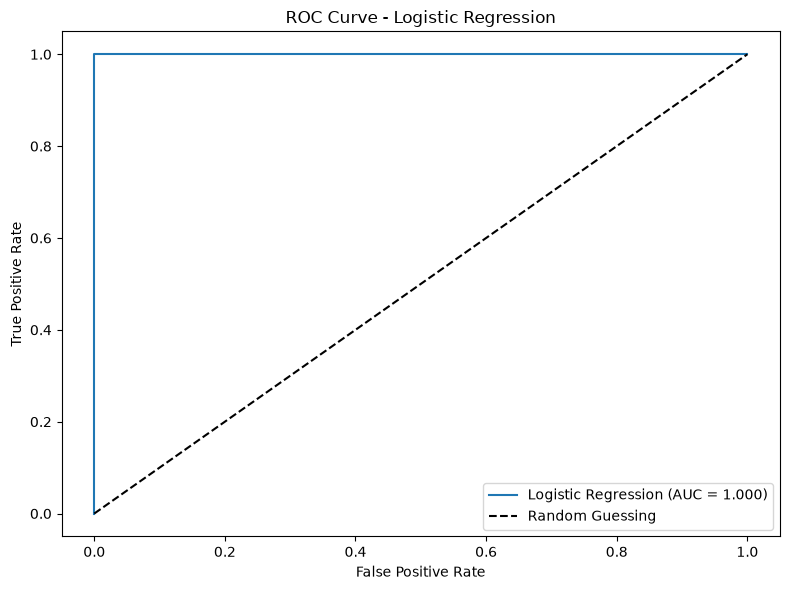

In [26]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.tight_layout()
plt.show()

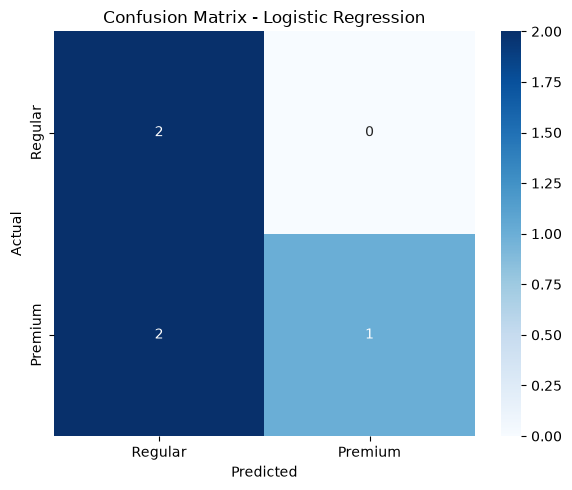

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Regular", "Premium"],
    yticklabels=["Regular", "Premium"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.show()

In [28]:
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(f"Dataset: {df.shape[0]} cars")
print(f"Features: Age, Miles")
print(f"Price threshold: ${THRESHOLD:.2f} thousand")

print(f"\nPremium cars: {(df['premium'] == 1).sum()}")
print(f"Regular cars: {(df['premium'] == 0).sum()}")

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")

print("\n" + "=" * 50)
print("KEY INSIGHT")
print("=" * 50)

print(
    "Logistic Regression was used to classify cars as "
    "Regular or Premium based on Age and Miles."
)

print(
    "Because the dataset is very small (25 cars), "
    "the evaluation results should be interpreted with caution."
)

FINAL SUMMARY
Dataset: 25 cars
Features: Age, Miles
Price threshold: $11.90 thousand

Premium cars: 13
Regular cars: 12

Accuracy:  0.6000
Precision: 1.0000
Recall:    0.3333
F1-Score:  0.5000
ROC-AUC:   1.0000

Mean CV Accuracy: 0.8800

KEY INSIGHT
Logistic Regression was used to classify cars as Regular or Premium based on Age and Miles.
Because the dataset is very small (25 cars), the evaluation results should be interpreted with caution.


Logistic Regression classified cars as Regular or Premium using Age and Miles. The model achieved 60% accuracy, 100% precision, 33.33% recall, 50% F1-score, and an ROC-AUC of 1.00 on the test set. Five-fold cross-validation produced a mean accuracy of 88%. The high precision indicates that cars predicted as Premium were correctly identified, while the low recall shows that the model missed several Premium cars. However, because the dataset contains only 25 observations, the evaluation results may be unstable and should be interpreted with caution.